In [3]:
import pandas as pd
import matplotlib.pyplot as plt

path = "../datasets/ROUND1/prices_round_1_day_-1.csv"

# Load CSV
df = pd.read_csv(path, sep=';')



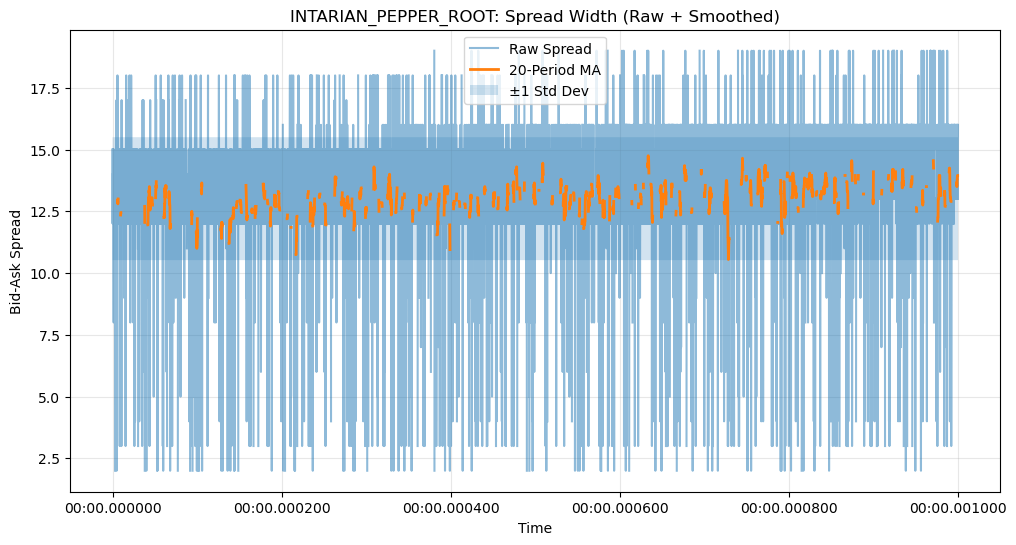

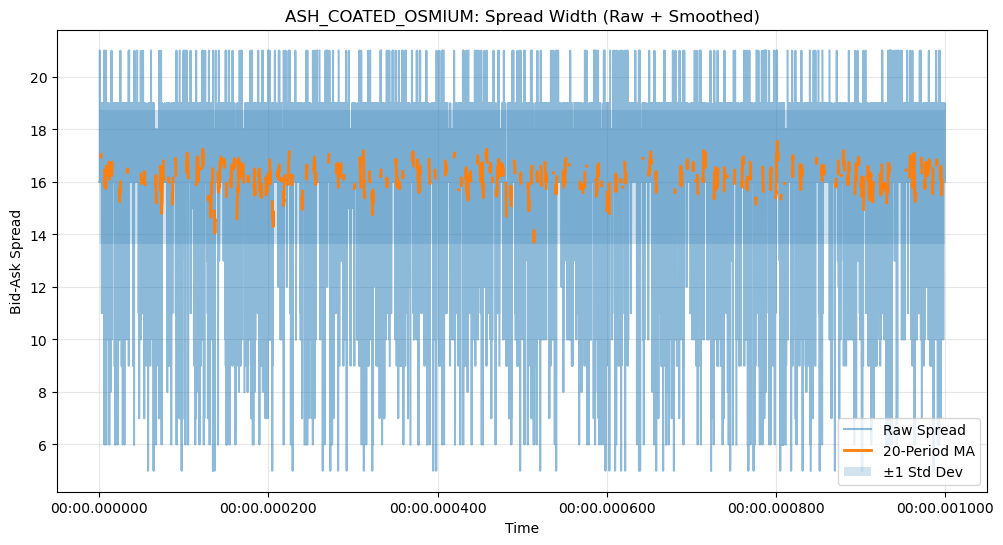

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['spread'] = df['ask_price_1'] - df['bid_price_1']

for product in df['product'].unique():
    product_data = df[df['product'] == product].sort_values('timestamp')
    product_data['spread_ma'] = product_data['spread'].rolling(window=20).mean()
    
    plt.figure(figsize=(12, 6))
    plt.plot(product_data['timestamp'], product_data['spread'], alpha=0.5, label='Raw Spread')
    plt.plot(product_data['timestamp'], product_data['spread_ma'], linewidth=2, label='20-Period MA')
    plt.fill_between(product_data['timestamp'], 
                      product_data['spread'].mean() - product_data['spread'].std(),
                      product_data['spread'].mean() + product_data['spread'].std(),
                      alpha=0.2, label='±1 Std Dev')
    plt.xlabel('Time')
    plt.ylabel('Bid-Ask Spread')
    plt.title(f'{product}: Spread Width (Raw + Smoothed)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()